# Praktika: Sare Neuronala

Praktika honetarako smart erlojuek neurtutako datuen arabera, pertsonen estres-maila aztertzen duen datu-bilduma jorratuko duzue. Horretarako [datu-bilduma hau](https://drive.google.com/file/d/12MhpFIyD8MoTgCOmHI9BKWlT1bi7LY6d/view?usp=sharing) erabiliko da. Hainbat aldagai azaltzen dira, hauen artean; bihotz taupadak, azalaren tenperatura edota jarduera fisiko maila.

Era berean, datu-bilduma honen klasea `label` zutabea da. Rested eta stressed aldagaiekin.

## 0. Ariketa: Prestaketak

In [148]:
## importak
###########
## pytorch
import torch
import torch.nn as nn
import torch.optim as optim

## sklearn, numpy, mpl, pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# grafikoen aurrekonfigurazioa
plt.style.use('seaborn-v0_8-whitegrid')

## CUDA?
print(f"PyTorch bertsioa: {torch.__version__}")
print(f"GPU erabilgai?: {torch.cuda.is_available()}")

# seed-ak ezarri
np.random.seed(42)
torch.manual_seed(42)

PyTorch bertsioa: 2.10.0+cpu
GPU erabilgai?: False


In [149]:
## datu bilduma kargatu
df = pd.read_csv('stress_sequences.csv')
df.tail()

,sequence_id,timestep,heart_rate_bpm,hrv_ms,blood_oxygen_pct,accel_g,resp_rate_bpm,skin_temp_c,gsr_microsiemens,noise_db,steps_per_min,sleep_debt_hours,activity_level,noise_environment,skin_temp_profile,gsr_state,label
11515,239,43,95.62,37.89,93.06,1.005,19.98,36.00,7.44,56.30,65,4.16,active,busy,cool,overstimulated,stressed
11516,239,44,92.39,43.03,93.56,0.534,18.84,36.05,8.33,55.64,62,4.16,active,busy,cool,overstimulated,stressed
11517,239,45,94.16,39.45,93.51,0.743,20.07,36.05,7.78,53.62,53,4.16,active,busy,cool,overstimulated,stressed
11518,239,46,98.21,41.24,92.77,0.701,19.81,36.02,8.04,61.10,53,4.16,active,loud,cool,overstimulated,stressed
11519,239,47,96.46,35.95,93.37,0.917,20.32,35.93,7.80,59.12,57,4.16,active,busy,cool,overstimulated,stressed


label
rested      9216
stressed    2304
Name: count, dtype: int64


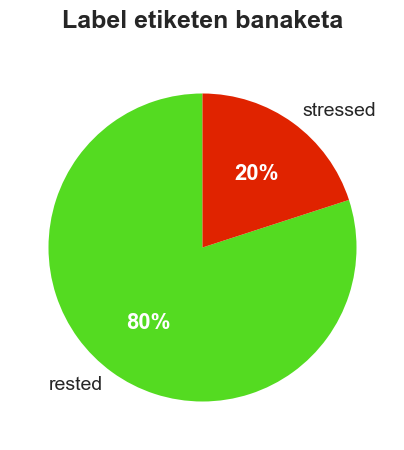

In [150]:
## label etiketen banaketa diagrama (pie chart)

label_counts = df['label'].value_counts()
print(label_counts)

# pie chart sortu
fig, ax = plt.subplots(figsize=(5, 5))

# koloreak
colors = ['#54DB21', '#E02300'] 

# grafikoa konfiguratu
wedges, texts, autotexts = ax.pie(
    label_counts.values, 
    labels=label_counts.index,
    autopct='%.0f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 14}
)

# Barruko ehunekoak
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(16)

ax.set_title('Label etiketen banaketa', fontsize=18, fontweight='bold', pad=20)

plt.show()
fig.savefig(fname='irudiak/pie_chart_label.pdf', format='pdf', dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')


In [151]:
## one hot encoding

one_hot_labels = pd.get_dummies(df["label"], dtype=int)
print(one_hot_labels)


       rested  stressed
0           1         0
1           1         0
2           1         0
3           1         0
4           1         0
...       ...       ...
11515       0         1
11516       0         1
11517       0         1
11518       0         1
11519       0         1

[11520 rows x 2 columns]


In [152]:
## label encoding

le = LabelEncoder()
df['activity_level'] = le.fit_transform(df["activity_level"])
df['noise_environment'] = le.fit_transform(df["noise_environment"])
df['skin_temp_profile'] = le.fit_transform(df["skin_temp_profile"])
df['gsr_state'] = le.fit_transform(df["gsr_state"])
df['label'] = le.fit_transform(df["label"])
print(df.head())

   sequence_id  timestep  heart_rate_bpm  ...  skin_temp_profile  gsr_state  label
0            0         0           67.16  ...                  1          0      0
1            0         1           69.96  ...                  1          0      0
2            0         2           67.92  ...                  1          0      0
3            0         3           63.26  ...                  1          0      0
4            0         4           67.55  ...                  1          0      0

[5 rows x 17 columns]


In [153]:
## informazio erabilgarria ematen duen grafika bat




In [154]:
## Train test banaketa

y = df["label"].values
X = df.drop(columns=["label"]).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 1. Ariketa: Sare Neuronal Eraketa
Sare Neuronalaren arkitektura jada eginda dago, baina parametroak zuek erabaki behar dituzue.

In [155]:
# Sare Neuronal sinplea
class SNAnomalyDetection(nn.Module):
    def __init__(self, sarrera_size, hidden1_size, hidden2_size, hidden3_size, irteera_size):
        super(SNAnomalyDetection, self).__init__()
        
        # geruzak definitzeko : nn.Linear
        self.hl1 = nn.Linear(
            sarrera_size,
            hidden1_size
        )  # sarrera -> hidden layer 1
        self.hl2 = nn.Linear(
            hidden1_size,
            hidden2_size
        )  # hidden layer 1 -> hidden layer 2
        self.hl3 = nn.Linear(
            hidden2_size,
            hidden3_size
        )  # hidden layer 2 -> hidden layer 3
        self.irteera = nn.Linear(
            hidden3_size,
            irteera_size
        )  # hidden layer 3 -> irteera
        
    def forward(self, x):
        # lehenengo geruza eta relu aplikatu
        x = self.hl1(x)
        x = torch.relu(x)
        # bigarren geruza eta relu aplikatu
        x = self.hl2(x)
        x = torch.relu(x)
        # hirugarren geruza eta relu aplikatu
        x = self.hl3(x)
        x = torch.relu(x)
        # irteera geruza eta sigmoid aplikatu
        x = self.irteera(x)
        x = torch.sigmoid(x)
        
        return x

In [156]:
# Entrenamendu funtzioa
def modeloa_entrenatu(modelo, X_train, y_train, X_test, y_test, 
                    epochs=48, learning_rate=0.01):
    """
    SN modelo entrenamendu metodoa
    
    Parametroak:
    - modelo: nn.Module ko isntantzia klasea
    - X_train, y_train: Entrenamendu datuak eta klaseak
    - X_test, y_test: Test datuak eta klaseak
    - epochs: epoka kopurua
    - learning_rate: Ikasketa tasa
    """
    
    # Errore funtzioa ezarri
    criterio = nn.BCELoss()
    
    # Pisuak birkalkulatzeko algoritmoa 
    optimizador = optim.Adam(modelo.parameters(), lr=learning_rate)
    
    # Historikoak
    train_losses = []
    test_losses = []
    
    print("Entrenamendua hasieratzen...")
    print("=" * 50)
    
    for epoch in range(epochs):
        # ==================== TRAINING ====================
        modelo.train()  # modeloa entrenamendu egoera jarri
        
        # Forward pass
        y_pred_train = modelo(X_train)
        loss_train = criterio(y_pred_train, y_train)
        
        # Backward pass
        optimizador.zero_grad()  # Aurreko gradienteak garbitu
        loss_train.backward()     # gradienteak garbitu
        optimizador.step()        # pisuak eguneratu
        
        # ==================== ERRORE EBALUAZIOA ====================
        modelo.eval()  # modeloa ebaluazio egoeran jarri (ikasi ez dezan)
        
        with torch.no_grad():  # EZIN DIRA GRADIENTEAK TESTEAN KALKULATU
            y_pred_test = modelo(X_test)
            loss_test = criterio(y_pred_test, y_test)
        
        train_losses.append(loss_train.item())
        test_losses.append(loss_test.item())
        
        # 10 epokako eboluzioa erakutsi
        if (epoch + 1) % 10 == 0:
            print(f"Epoka {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {loss_train.item():.4f} | "
                  f"Test Loss: {loss_test.item():.4f}")
    
    print("=" * 50)
    print("Entrenamendua bukatuta!")
    
    return train_losses, test_losses

Entrenamendua hasieratzen...
Epoka  10/50 | Train Loss: 0.1339 | Test Loss: 0.1252
Epoka  20/50 | Train Loss: 0.1145 | Test Loss: 0.1054
Epoka  30/50 | Train Loss: 0.1064 | Test Loss: 0.0978
Epoka  40/50 | Train Loss: 0.0988 | Test Loss: 0.0908
Epoka  50/50 | Train Loss: 0.0916 | Test Loss: 0.0842
Entrenamendua bukatuta!


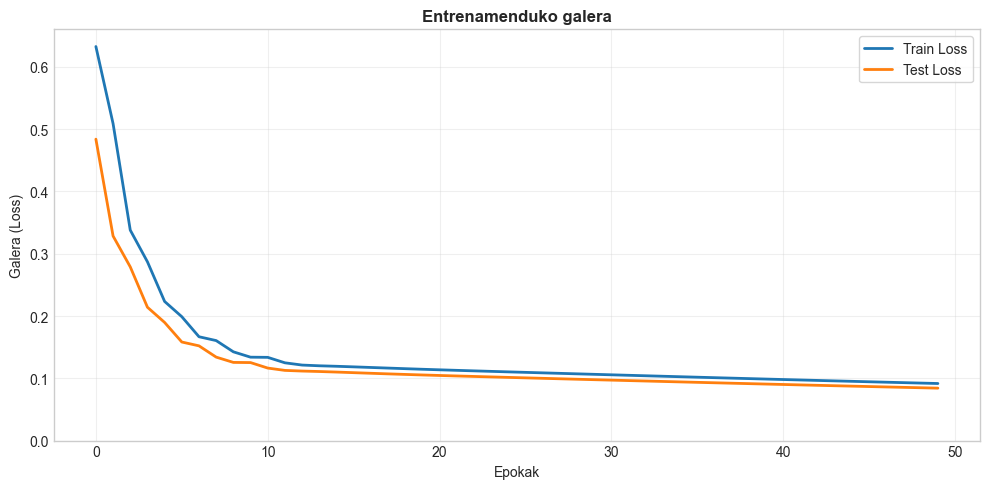

In [159]:
## Modeloa entrenatu
# kargatu
modelo = SNAnomalyDetection(sarrera_size=X_train.shape[1], hidden1_size=32, hidden2_size=16, hidden3_size=8, irteera_size=1)
# entrenatu 100 epokatan

# Aldatu X_train, y_train, X_test, y_test tentsore izateko, PyToerch lan egin ahal izateko
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
train_losses, test_losses = modeloa_entrenatu(
    modelo, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor,
    epochs=50, learning_rate=0.01
)

# Errore galera grafika
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epokak')
plt.ylabel('Galera (Loss)')
plt.ylim(bottom=0)
plt.title('Entrenamenduko galera', fontweight='bold')
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.1. Ariketa: Sare Neuronal Ebaluazioa
- Overfitting al dago?
- Sailkapena denez, nolakoa da nahasmen-matrizea?

## 2. Ariketa: Beste algoritmo batekin konparazioa

Nahiz eta sare neuronalek emaitza oso onak eman, beste algoritmoek zer nolako emaitzak ematen duten ikusi behar da. Adibidez; iragarpen berriak kalkulatzeko denbora, accuracy emaitza hobeak, ...

In [158]:
## erabaki duzun algoritmoa jorratu




## 3. Ariketa: Ondorioak
Zure ondorioak idatzi ...